In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
df= pd.read_csv('../data/parkinsons_updrs.data')

In [ ]:
df

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5870,42,61,0,142.7900,22.485,33.485,0.00406,0.000031,0.00167,0.00168,...,0.160,0.00973,0.01133,0.01549,0.02920,0.025137,22.369,0.64215,0.55314,0.21367
5871,42,61,0,149.8400,21.988,32.988,0.00297,0.000025,0.00119,0.00147,...,0.215,0.01052,0.01277,0.01904,0.03157,0.011927,22.886,0.52598,0.56518,0.12621
5872,42,61,0,156.8200,21.495,32.495,0.00349,0.000025,0.00152,0.00187,...,0.244,0.01371,0.01456,0.01877,0.04112,0.017701,25.065,0.47792,0.57888,0.14157
5873,42,61,0,163.7300,21.007,32.007,0.00281,0.000020,0.00128,0.00151,...,0.131,0.00693,0.00870,0.01307,0.02078,0.007984,24.422,0.56865,0.56327,0.14204


In [23]:
num_features = [features for features in df.columns if df[features].dtypes != 'O']
print('Number of numerical features: ', len(num_features))
cat_features = [features for features in df.columns if df[features].dtypes == 'O']
print('Number of categorical features: ', len(cat_features))
dis_features = [features for features in df.columns if len(df[features].unique()) < 25 and df[features].dtypes != 'O']
print('Number of discrete features: ', len(dis_features))
con_features = [features for features in df.columns if len(df[features].unique()) >= 25 and df[features].dtypes != 'O']
print('Number of continuous features: ', len(con_features))

Number of numerical features:  22
Number of categorical features:  0
Number of discrete features:  2
Number of continuous features:  20


In [24]:
df=df.drop(columns=['subject#'])

In [25]:
X = df.drop(columns=['motor_UPDRS', 'total_UPDRS'])
y = df['total_UPDRS']

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.81569539, -0.68250887, -1.63209025, ..., -1.21406557,
        -1.47849968, -0.65065821],
       [ 0.81569539, -0.68250887, -1.5006763 , ..., -1.05511879,
        -1.24788006, -1.21858474],
       [ 0.81569539, -0.68250887, -1.36941017, ..., -0.78485974,
        -1.5401393 , -0.10328021],
       ...,
       [-0.43136086, -0.68250887,  1.19676305, ..., -0.62937908,
        -1.04885603, -0.85275524],
       [-0.43136086, -0.68250887,  1.32606439, ...,  0.26914065,
        -1.26903782, -0.8476181 ],
       [-0.43136086, -0.68250887,  1.45704984, ...,  0.44175389,
        -1.163249  , -0.72388969]], shape=(5875, 19))

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4700, 19), (1175, 19), (4700,), (1175,))

In [30]:
from sklearn.ensemble import RandomForestRegressor

In [31]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
y_pred = rf_model.predict(X_test)

In [33]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [34]:
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mse)
print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)

MSE: 2.571836320979604
MAE: 0.7158765029787223
RMSE: 1.6036945846948552


In [35]:
estimators = [10, 50, 100, 200, 300, 500]
rmse_scores = []

for n in estimators:
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    rmse_scores.append(rmse)
    print(f'n_estimators={n:4d}  →  RMSE: {rmse:.4f}')

n_estimators=  10  →  RMSE: 1.7721
n_estimators=  50  →  RMSE: 1.6465
n_estimators= 100  →  RMSE: 1.6037
n_estimators= 200  →  RMSE: 1.5796
n_estimators= 300  →  RMSE: 1.5666
n_estimators= 500  →  RMSE: 1.5734


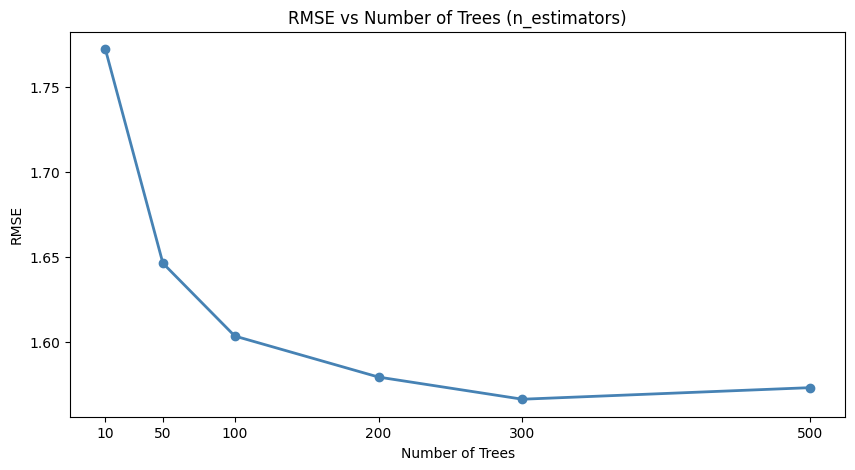


✅ Best n_estimators: 300


In [36]:
plt.figure(figsize=(10, 5))
plt.plot(estimators, rmse_scores, marker='o', color='steelblue', linewidth=2)
plt.title('RMSE vs Number of Trees (n_estimators)')
plt.xlabel('Number of Trees')
plt.ylabel('RMSE')
plt.xticks(estimators)
plt.show()

best_n = estimators[np.argmin(rmse_scores)]
print(f'\n✅ Best n_estimators: {best_n}')

In [37]:
best_rf_model = RandomForestRegressor(n_estimators=best_n, random_state=42)
best_rf_model.fit(X_train, y_train)
y_pred = best_rf_model.predict(X_test)

In [38]:
mae  = mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'MAE  : {mae:.4f}')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}')


MAE  : 0.7099
MSE  : 2.4542
RMSE : 1.5666
R²   : 0.9779
